# Lesson 2:  Data Warehousing & Multidimensional Analysis

## Objective
In this lab, we transition from simple data manipulation to **Architectural Thinking**. We will simulate a real-world enterprise environment for a global electronics retailer, **"ElectroGlobal Corp."**

### Key Concepts:
1.  **Data Lake vs. Data Warehouse**: Simulating Schema-on-Read and Schema-on-Write.
2.  **Star Schema Design**: Organizing data into Fact and Dimension tables.
3.  **OLAP Operations**: 
    *   **Slice & Dice** (Advanced Filtering)
    *   **Roll-up & Drill-down** (Hierarchical Aggregation)
    *   **Pivot** (Multi-dimensional Reshaping)
4.  **Data Cubing**: Understanding the multidimensional space.
5.  **Curse of Dimensionality**: Why we aggregate data.
---

## Part 1: The Data Lake Simulation (Schema-on-Read)

Imagine our retailer receives raw logs from various IoT devices, web stores, and physical registers in **JSON and CSV format**. This is our **Data Lake**. It's messy, nested, and unstructured.

### Dataset Generation
We will generate the two datasets files mimicing the real electonic stores, one dataset for the sales logs and another for the transcation details on the certain time frame. For this dataset, we will be creating the 10k rows each and the files will be in different fromats. We are trying to mimic the data lake, from our theroy. For this we are using the numpy and random numbers generator plus we are adding the noises at the random locations.

In [1]:
import pandas as pd
import numpy as np
import json
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'plotly'

In [2]:
# 1. Data Generation using NumPy (Simulating a real Data Lake)

np.random.seed(np.random.randint(0, 1000)) # Random seed for different runs
num_rows = 10000

products = ["Laptop", "Mouse", "Phone", "TV", "Cables", "Monitor", "Keyboard"]
base_prices = [1200, 25, 800, 1500, 15, 300, 100]
stores = ["London-01", "Paris-05", "NYC-02", "Tokyo-04", "Berlin-03"]

data_list = []
for i in range(num_rows):
    prod_idx = np.random.randint(0, len(products))
    # Add noise to price (+/- 15%)
    price_noise = np.random.uniform(0.85, 1.15)
    price = round(base_prices[prod_idx] * price_noise, 2)
    qty = np.random.randint(1, 10)
    
    # Random Date in 2023
    start_date = pd.to_datetime('2023-01-01')
    random_days = np.random.randint(0, 365)
    txn_date = (start_date + pd.Timedelta(days=random_days)).strftime('%Y-%m-%d')
    
    txn_id = f"TXN{i:05d}"
    store = np.random.choice(stores)
    
    # Adding random noise: 1% chance of null store or zero price
    if np.random.rand() < 0.01:
        store = None if np.random.rand() > 0.5 else "UNKNOWN"
    if np.random.rand() < 0.01:
        price = 0

    entry = {
        "transaction_id": txn_id,
        "meta": {"date": txn_date, "store": store},
        "items": [{"prod": products[prod_idx], "qty": qty, "price": price}]
    }
    data_list.append(entry)

# Save to JSON file
with open('raw_data.json', 'w') as f:
    json.dump(data_list, f)

# Save to CSV file (to simulate mixed source ingestion)
csv_data = pd.DataFrame([{
    'TXN_ID': d['transaction_id'], 
    'Date': d['meta']['date'], 
    'Store': d['meta']['store'], 
    'Product': d['items'][0]['prod'], 
    'Qty': d['items'][0]['qty'], 
    'Price': d['items'][0]['price']
} for d in data_list])

csv_data.to_csv('raw_data.csv', index=False)
print("[SYSTEM] Saved: raw_data.json, raw_data.csv")


[SYSTEM] Saved: raw_data.json, raw_data.csv


**EXPLANATION:**

On above step, we have generated 10,000 random records using NumPy, saved them to files, and read them back. This simulates a high-velocity Data Lake where data is stored in various formats. The noise added (nulls/zeros) allows us to practice Data Cleaning later in the ETL phase.

### Normalizing Nested JSON
On next step, we will use `pd.json_normalize` to flatten this raw data, simulating the ingestion process of a Data Lakehouse.

In [13]:
# 2. Reading JSON data back from the file (Data Lake Ingestion)
with open('raw_data.json', 'r') as f:
    raw_json_data = json.load(f)

print(f"[+] Ingested {len(raw_json_data)} records into the Data Lake.")

# 3. Schema-on-Read: Flattening the data for analysis
lake_df = pd.json_normalize(
    raw_json_data, 
    record_path=['items'], 
    meta=[['meta', 'date'], ['meta', 'store'], 'transaction_id']
)

lake_df.columns = ['Product', 'Quantity', 'Price', 'Date', 'Store', 'TXN_ID']
print("--- Raw Data Lake Content (Flattened Preview) ---")
print(lake_df.head())


[+] Ingested 10000 records into the Data Lake.
--- Raw Data Lake Content (Flattened Preview) ---
    Product  Quantity   Price        Date      Store    TXN_ID
0  Keyboard         4  107.86  2023-11-23  London-01  TXN00000
1    Cables         4   14.67  2023-03-26  Berlin-03  TXN00001
2     Mouse         4   24.30  2023-08-08   Paris-05  TXN00002
3     Phone         8  799.48  2023-08-07  Berlin-03  TXN00003
4     Phone         1  697.70  2023-04-06  Berlin-03  TXN00004


## Part 2: Building the Data Warehouse (Schema-on-Write)

To make this data useful for business executives, we must move it to a **Data Warehouse**. 
We will implement a **Star Schema**:
1.  **Fact Table**: Contains the measurable, quantitative data (Sales, Profit).
2.  **Dimension Tables**: Contain descriptive attributes (Product Details, Location, Time).

### Concept: Integration & Standardization
We will standardize the dates into Quarters and Months to build our **Concept Hierarchy** for later Roll-up/Drill-down operations.

In [14]:
# 1. Cleaning & Transformation
lake_df['Date'] = pd.to_datetime(lake_df['Date'])
lake_df['Year'] = lake_df['Date'].dt.year
lake_df['Quarter'] = 'Q' + lake_df['Date'].dt.quarter.astype(str)
lake_df['Month'] = lake_df['Date'].dt.month_name()
lake_df['Revenue'] = lake_df['Quantity'] * lake_df['Price']

# --- DATA QUALITY GATE (ETL Cleaning) ---
# Remove rows where Store is null / 'UNKNOWN' or Price is 0
# (these are the noise records we intentionally injected into the Data Lake)
before = len(lake_df)
lake_df = lake_df.dropna(subset=['Store'])               # drop null stores
lake_df = lake_df[lake_df['Store'] != 'UNKNOWN']         # drop UNKNOWN stores
lake_df = lake_df[lake_df['Price'] > 0]                  # drop zero-price records
after  = len(lake_df)
print(f'[ETL] Cleaned {before - after} noisy records ({before} → {after} rows)')

# 2. Dimension Table: Time
dim_time = lake_df[['Date', 'Year', 'Quarter', 'Month']].drop_duplicates()

# 3. Fact Table: Sales
# A Fact Table usually contains Foreign Keys to Dimensions and the Measures.
fact_sales = lake_df[['TXN_ID', 'Product', 'Store', 'Date', 'Revenue', 'Quantity']]

print("--- Fact Table (Sales) Preview ---")
print(fact_sales.head())

[ETL] Cleaned 198 noisy records (10000 → 9802 rows)
--- Fact Table (Sales) Preview ---
     TXN_ID   Product      Store       Date  Revenue  Quantity
0  TXN00000  Keyboard  London-01 2023-11-23   431.44         4
1  TXN00001    Cables  Berlin-03 2023-03-26    58.68         4
2  TXN00002     Mouse   Paris-05 2023-08-08    97.20         4
3  TXN00003     Phone  Berlin-03 2023-08-07  6395.84         8
4  TXN00004     Phone  Berlin-03 2023-04-06   697.70         1


**EXPLANATION:**

The ETL pipeline applies a DATA QUALITY GATE before writing to the Warehouse.
Records with null/unknown stores or zero prices are rejected here — NOT in
the analytics layer. This is the correct pattern:

 **Data Lake (raw, noisy)  ──►  ETL (clean & validate)  ──►  Warehouse (trusted)**

Doing the cleaning here means every downstream report is automatically correct. This is the **'Schema-on-Write'** phase. We have transformed raw, messy data into 
structured Fact and Dimension tables and saved them into a persistent Warehouse.
Business tools can now query these tables directly.


## Part 3: OLAP Operations

Now we will use the **Data Cube** approach to analyze our sales.

### 1. Slice & Dice (The Surgical Tools)
-   **Slice**: A selection on one dimension (e.g., Only 'Laptop' sales).
-   **Dice**: A sub-cube selecting multiple dimensions (e.g., 'Laptop' in 'London' during 'Q1').

In [15]:
# SLICE: Look at only one product across all time and space
slice_laptop = lake_df[lake_df['Product'] == 'Laptop']

# DICE: Look at a specific intersection
dice_london_q1_laptops = lake_df[
    (lake_df['Store'].str.contains('London')) & 
    (lake_df['Quarter'] == 'Q1') & 
    (lake_df['Product'] == 'Laptop')
]

print(f"Slice (Laptops) Total Revenue: ${slice_laptop['Revenue'].sum():,.2f}")
print(f"Dice (London, Q1, Laptops) Revenue: ${dice_london_q1_laptops['Revenue'].sum():,.2f}")

Slice (Laptops) Total Revenue: $8,928,433.27
Dice (London, Q1, Laptops) Revenue: $522,229.37


### 2. Roll-up & Drill-down (The Zoom Tools)

**Roll-up** aggregates data by moving **UP** a hierarchy (e.g., Month -> Quarter).
**Drill-down** breaks down data by moving **DOWN** a hierarchy (e.g., Quarter -> Month).

### Pandas MultiIndex for Hierarchies

In [16]:
# Creating a Hierarchical Data Cube using MultiIndex
cube = lake_df.groupby(['Year', 'Quarter', 'Month', 'Store', 'Product'])['Revenue'].sum()

print("--- The Multidimensional Cube (MultiIndex) ---")
print(cube.head(10))

# ROLL-UP: Move from Month/Product level up to just Quarter/Store level
rollup_quarterly = cube.groupby(level=['Year', 'Quarter', 'Store']).sum()
print("\n--- Roll-up: Quarterly Sales by Store ---")
print(rollup_quarterly)

# DRILL-DOWN: Move from a high level down to specific months
drilldown_q1 = cube.loc[2023, 'Q1']
print("\n--- Drill-down: Q1 Broken down by Month, Store, and Product ---")
print(drilldown_q1)

--- The Multidimensional Cube (MultiIndex) ---
Year  Quarter  Month     Store      Product 
2023  Q1       February  Berlin-03  Cables        2124.06
                                    Keyboard     11693.94
                                    Laptop      132745.20
                                    Monitor      34468.97
                                    Mouse         2413.18
                                    Phone        89416.71
                                    TV          135111.31
                         London-01  Cables         985.13
                                    Keyboard      8575.95
                                    Laptop      162294.29
Name: Revenue, dtype: float64

--- Roll-up: Quarterly Sales by Store ---
Year  Quarter  Store    
2023  Q1       Berlin-03    1405265.20
               London-01    1489159.56
               NYC-02       1288325.89
               Paris-05     1354259.34
               Tokyo-04     1474027.35
      Q2       Berlin-03    1317710

**EXPLANATION:**

The **groupby()** function with multiple columns creates a **'Lattice of Cuboids'**. 
Each level of the index represents a dimension. By using .groupby(level=...), 
we are programmatically performing a Roll-up operation.

### 3. Pivot (The Perspective Tool)

Pivoting rotates the data axes to view it from a different perspective. This is how modern Business Intelligence (BI) tools like Tableau or PowerBI work.

--- Pivot Table: Product Sales across Stores ---
Store      Berlin-03   London-01      NYC-02    Paris-05    Tokyo-04
Product                                                             
Cables      20482.03    20519.77    19960.12    21341.64    20339.09
Keyboard   145746.74   130281.80   148703.77   140303.28   135853.98
Laptop    1811266.23  1849190.45  1773600.44  1802075.72  1692300.43
Monitor    424046.40   440563.95   417201.13   400006.26   496220.27
Mouse       36311.69    38927.43    35975.33    32729.79    32009.21
Phone     1116051.02  1070630.82  1206809.97  1278357.23  1107715.17
TV        2058490.82  2122459.18  1818866.11  2248920.25  1760114.58


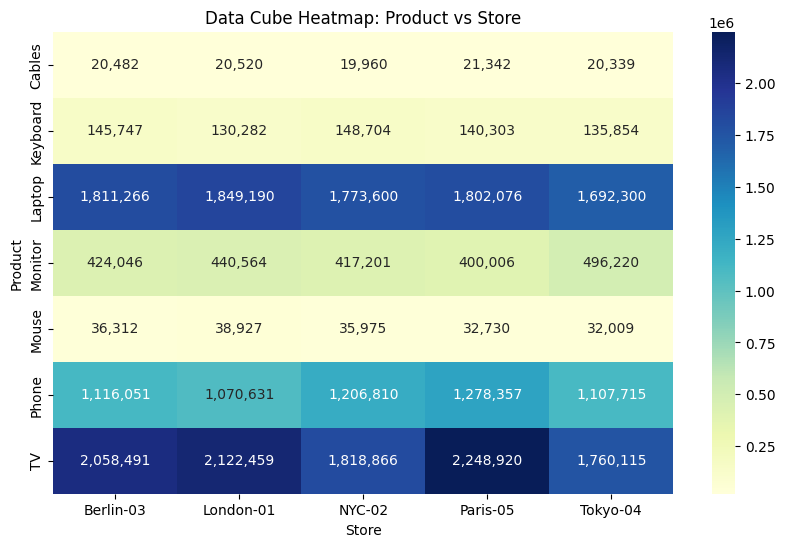

In [17]:
# PIVOT: Rotating the axes to see Product vs Store
pivot_table = lake_df.pivot_table(
    values='Revenue', 
    index='Product', 
    columns='Store', 
    aggfunc='sum', 
    fill_value=0
)

print("--- Pivot Table: Product Sales across Stores ---")
print(pivot_table)

# VISUALIZING THE PIVOT (Heatmap)
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt=",.0f", cmap="YlGnBu")
plt.title("Data Cube Heatmap: Product vs Store")
plt.show()

## Part 4: The Algorithmic Concept - Curse of Dimensionality

In Lesson 2 theory, we discuss the **Curse of Dimensionality**. 

**What is it?**
As we add more dimensions (Product, Store, Time, Customer Age, Payment Method, Weather, etc.), the number of possible cells in our "Data Cube" grows exponentially. 

**The Problem:**
If you have 100 products, 50 stores, and 365 days, your cube has $100 \times 50 \times 365 = 1,825,000$ possible cells. 
However, most cells will be **empty** (sparse) because a specific product might not sell in a specific store on a specific day.

**The Solution:**
This is why we use **Materialized Views** and **Data Compression**. Instead of storing every empty cell, we store only the non-empty ones (Sparse Cubes).

In [18]:
# Calculating Sparsity
total_possible_combinations = len(lake_df['Product'].unique()) * len(lake_df['Store'].unique()) * len(lake_df['Quarter'].unique())
actual_combinations = len(lake_df.groupby(['Product', 'Store', 'Quarter']))

sparsity = (1 - (actual_combinations / total_possible_combinations)) * 100

print(f"Total Possible Cube Cells: {total_possible_combinations}")
print(f"Actual Data Points: {actual_combinations}")
print(f"Cube Sparsity: {sparsity:.2f}%")

Total Possible Cube Cells: 140
Actual Data Points: 140
Cube Sparsity: 0.00%


**OBSERVATION:**

In real big data, sparsity is often > 99%. This is why 'Data Mining' is called mining—
we are looking for small nuggets of knowledge in a massive, mostly empty space.

## Part 5: Visualizations for Data Cubes

To truly "wow" a business stakeholder, we don't just show tables. We show hierarchies.

In [19]:
# TREEMAP: Visualizing the Roll-up Hierarchy (Store -> Product)
fig = px.treemap(
    lake_df, 
    path=['Store', 'Product'], 
    values='Revenue',
    title="Hierarchical Sales Analysis (Roll-up Visualization)",
    color='Revenue',
    color_continuous_scale='RdBu'
)
fig.show()



**EXPLANATION:**

A Treemap is the perfect visual representation of an OLAP Cube. 
The large boxes represent the top-level dimension (Store), 
and the inner boxes represent the drill-down level (Product).

##  Summary

1.  **Data Lake**: We saw how raw JSON (unstructured) and csv is stored.
2.  **ETL (Extract, Transform, Load)**: We cleaned the data and added time hierarchies.
3.  **Star Schema**: We separated the data into Facts (Revenue) and Dimensions (Store, Product).
4.  **OLAP Operations**: We performed Slice, Dice, Roll-up, Drill-down, and Pivot.
5.  **BI Insights**: We used Heatmaps and Treemaps to communicate knowledge.

--- 
### Lab Challenge for You Before Tommorow Session:
Try to add a new dimension: **'Payment_Method'** (e.g., Credit Card, Cash, Bitcoin) to the raw JSON and perform a **Dice** operation to find Bitcoin sales of Laptops in London.